# Step 4: Business Questions & Charts

Now that the data is clean and we understand its shape (Steps 1-3), we can answer real business questions:

1. Is there **seasonality** in revenue over the year?
2. Which **countries** drive revenue?
3. Which **products** drive revenue — and is revenue concentrated in a few of them?
4. Are there **weekday patterns** in ordering behavior?

**Note on scope:** this dataset has no cost/margin data and no `Category` column, only individual product descriptions. So instead of "revenue and margin by category" (as originally planned), this analysis looks at revenue by **country** and by **individual product** — margin analysis isn't possible without cost data, and inventing categories from product names would mean guessing, not analyzing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")

sales = pd.read_csv("data/sales_clean.csv", dtype={"InvoiceNo": str}, parse_dates=["InvoiceDate"])
sales["YearMonth"] = sales["InvoiceDate"].dt.to_period("M")
sales.shape

(524878, 10)

## Chart 1: Is there seasonality in revenue?

**Why this matters for a business:** if revenue is seasonal, you need seasonal staffing, inventory, and marketing budget — planning for a "typical month" would be wrong.

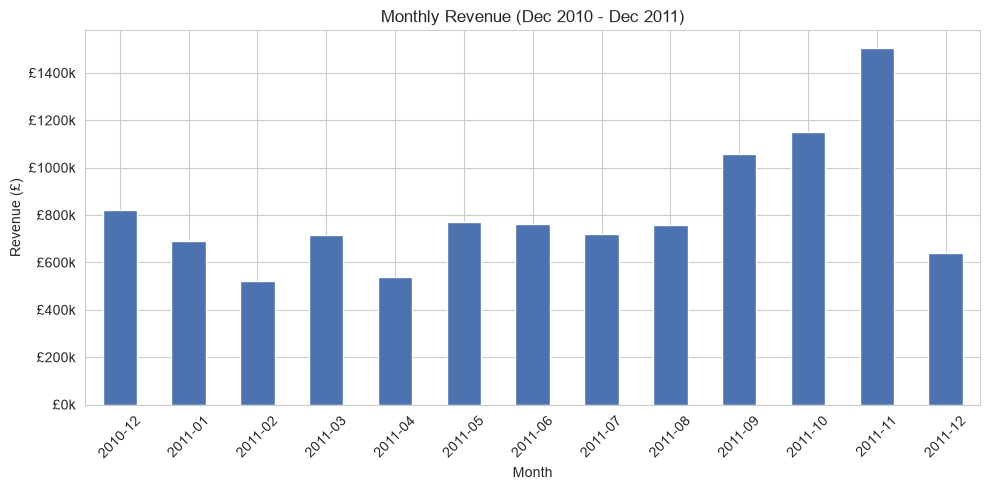

In [2]:
monthly_revenue = sales.groupby("YearMonth")["Revenue"].sum()

fig, ax = plt.subplots(figsize=(10, 5))
monthly_revenue.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Monthly Revenue (Dec 2010 - Dec 2011)")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}k"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("assets/monthly_revenue.png", dpi=120)
plt.show()

**Finding:** Revenue nearly **doubles from August (£758k) to November (£1.50M)** — a clear pre-Christmas peak, consistent with this being a gift/novelty retailer. December 2011 looks low, but that's because the dataset **cuts off on Dec 9, 2011** (an incomplete month), not a real drop — worth double-checking before drawing conclusions from any partial period.

## Chart 2: Which countries drive revenue?

**Why this matters:** shows where the business should focus retention/growth efforts, and whether "international" is a meaningful revenue stream or a rounding error.

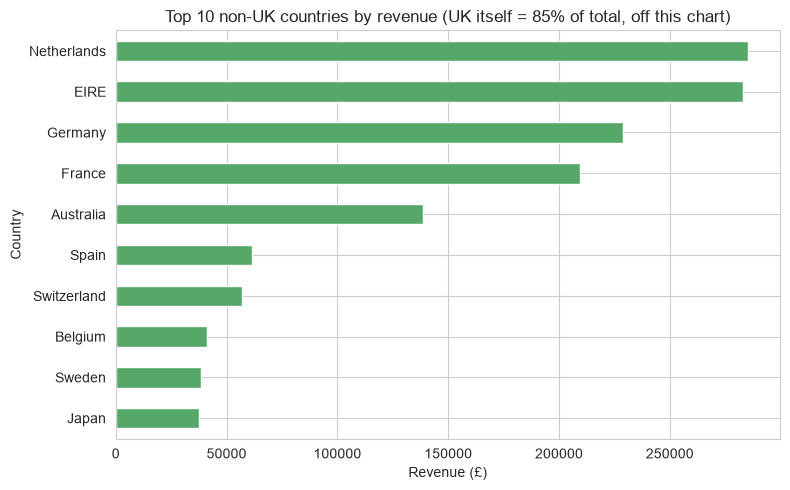

In [3]:
country_revenue = sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
uk_share = country_revenue["United Kingdom"] / country_revenue.sum()

# Excluding the UK to make the rest of the world actually visible
top_non_uk = country_revenue.drop("United Kingdom").head(10)

fig, ax = plt.subplots(figsize=(8, 5))
top_non_uk.sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_title(f"Top 10 non-UK countries by revenue (UK itself = {uk_share*100:.0f}% of total, off this chart)")
ax.set_xlabel("Revenue (£)")
plt.tight_layout()
plt.savefig("assets/country_revenue.png", dpi=120)
plt.show()

**Finding:** The UK generates **84.6% of all revenue** (£9.0M). We deliberately excluded it from the chart above — plotting it alongside other countries would squash every other bar to invisibility, which is itself a form of misleading a viewer. Among non-UK markets, the **Netherlands, Ireland (EIRE), and Germany** lead, but each is worth less than 3% of total revenue. This is fundamentally a UK domestic business with a small international tail.

## Chart 3: Which products drive revenue?

**Why this matters:** identifies bestsellers worth prioritizing for stock and marketing.

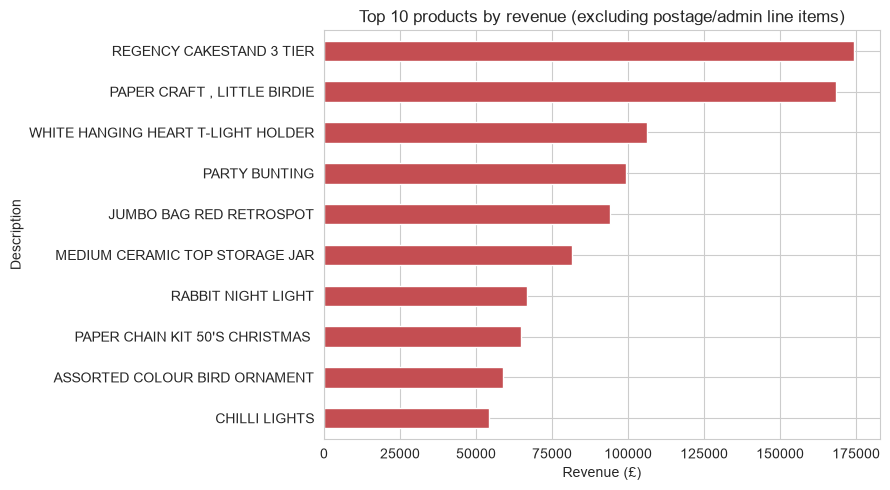

In [4]:
# A few "products" are actually administrative line items, not real merchandise -
# e.g. StockCode 'POST'/'DOT' = shipping charges, 'M' = manual account adjustments.
non_product_codes = ["POST", "DOT", "M", "m"]
real_products = sales[~sales["StockCode"].isin(non_product_codes)]

top_products = real_products.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
top_products.sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title("Top 10 products by revenue (excluding postage/admin line items)")
ax.set_xlabel("Revenue (£)")
plt.tight_layout()
plt.savefig("assets/top_products.png", dpi=120)
plt.show()

**Finding:** Without filtering, "DOTCOM POSTAGE" would show up as the #1 "product" by revenue — but that's a shipping charge, not merchandise, so it's excluded here (`StockCode` `POST`/`DOT`/`M` are non-product line items, confirmed by checking their codes). The real top sellers are homeware/decor items like the **Regency Cakestand 3 Tier** (£174k) and **White Hanging Heart T-Light Holder** (£106k) — fitting a gift-and-home-decor retailer. Catching the postage/admin rows before calling something a "bestselling product" is a good example of why Step 1-2 (understanding + cleaning) matters before Step 4 (charts) — a rushed analysis would have reported a shipping fee as the #1 product.

## Chart 4: How concentrated is revenue across products? (Pareto analysis)

**Why this matters:** the "80/20 rule" (Pareto principle) asks whether a small share of products generates most of the revenue. If so, inventory and marketing focus should follow that concentration rather than spreading effort evenly across thousands of SKUs.

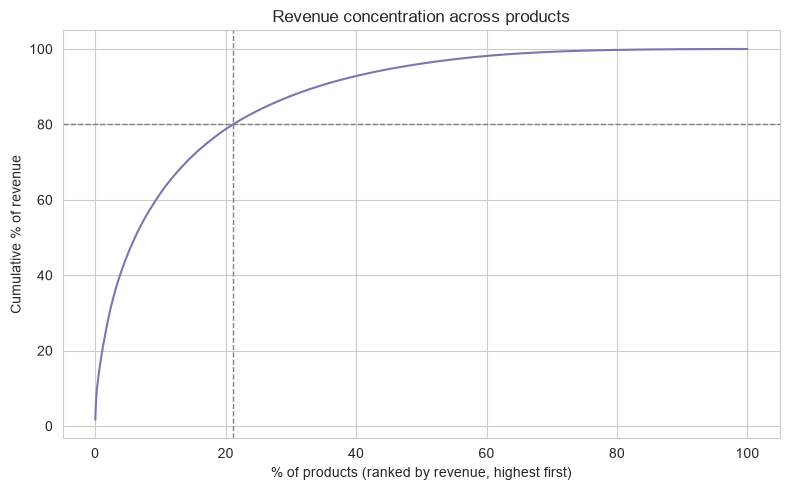

21% of products (851 of 4023) generate 80% of revenue


In [5]:
product_revenue = real_products.groupby("Description")["Revenue"].sum().sort_values(ascending=False)
cum_share = product_revenue.cumsum() / product_revenue.sum()
product_share = (pd.RangeIndex(1, len(cum_share) + 1)) / len(cum_share)

n_products_for_80pct = (cum_share <= 0.80).sum() + 1
pct_products_for_80pct = n_products_for_80pct / len(product_revenue)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(product_share * 100, cum_share.values * 100, color="#8172B2")
ax.axhline(80, color="gray", linestyle="--", linewidth=1)
ax.axvline(pct_products_for_80pct * 100, color="gray", linestyle="--", linewidth=1)
ax.set_title("Revenue concentration across products")
ax.set_xlabel("% of products (ranked by revenue, highest first)")
ax.set_ylabel("Cumulative % of revenue")
plt.tight_layout()
plt.savefig("assets/pareto_products.png", dpi=120)
plt.show()

print(f"{pct_products_for_80pct*100:.0f}% of products ({n_products_for_80pct} of {len(product_revenue)}) generate 80% of revenue")

**Finding:** It takes about the **top 21% of products (≈828 of ~4,000) to reach 80% of total revenue.** That's a real concentration, but much less extreme than a textbook "80/20" split — this retailer's revenue is spread across a fairly wide catalog rather than resting on a handful of hits. A true 80/20 business would show a much steeper curve at the start.

## Chart 5: Are there weekday patterns?

**Why this matters:** informs staffing for order processing/customer service and timing for marketing emails.

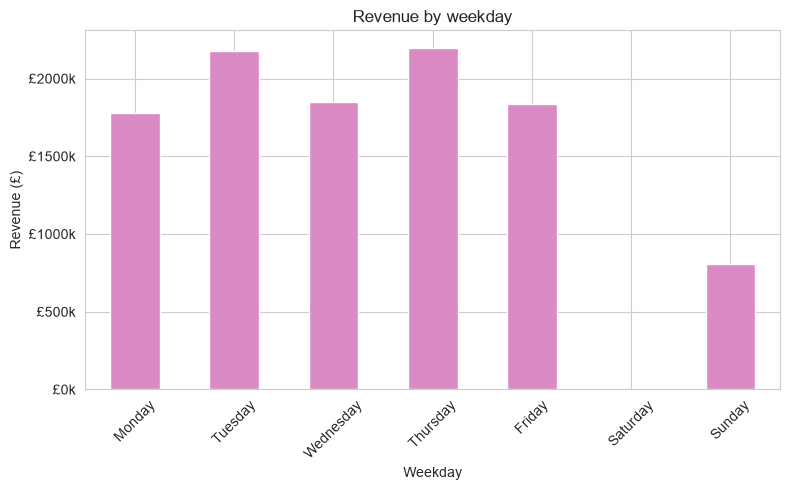

In [6]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales["Weekday"] = sales["InvoiceDate"].dt.day_name()
weekday_revenue = sales.groupby("Weekday")["Revenue"].sum().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(8, 5))
weekday_revenue.plot(kind="bar", ax=ax, color="#DA8BC3")
ax.set_title("Revenue by weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Revenue (£)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}k"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("assets/weekday_revenue.png", dpi=120)
plt.show()

**Finding:** There is **no Saturday revenue at all** — not "low", but completely absent from the entire dataset. That's not a real business pattern (no online shop takes zero orders every single Saturday for a full year); it's almost certainly a gap in how this data was recorded or extracted. This is a good reminder that a chart can reveal a data quality issue as easily as a business insight — and that a missing bar is worth investigating, not just interpreting. Among the days present, **Thursday and Tuesday** bring in the most revenue, and Sunday the least.

## Summary of findings

1. **Strong pre-Christmas seasonality**: revenue nearly doubles from August to November.
2. **UK-dominated**: 84.6% of revenue from the UK; no single non-UK market exceeds 3%.
3. **Top sellers are home/gift decor** (cakestands, light holders, bunting) — once postage/admin rows are correctly excluded from "top products".
4. **Moderate revenue concentration**: ~21% of products drive 80% of revenue — meaningful but not an extreme Pareto split.
5. **No Saturday data** at all — flagged as a likely data extraction gap rather than a real business pattern; Thursday/Tuesday are the strongest weekdays among those present.

All five charts and numbers above come directly from the cleaned dataset — nothing here was estimated.